# CMME - Computational Methods in Mathematical Economics

Let us consider a two-dimensional deterministic macroeconomic model (the Ramsey model), which can be viewed as a simplified version of the RBC model


In [1]:
import tensorflow as tf
import numpy as np
import sys
from matplotlib import pyplot as plt
from scipy.optimize import fsolve

In [2]:
beta = 0.96; # discount factor
alpha = 1/3; # elasticity of production wrt capital
A     = 1.0; # TFP
sigma = 1.0; # 1/elasticity of intertemporal substitution
delta = 0.1; # depreciation rate

In [3]:
k_SS  = ((1/beta-1+delta)/(alpha*A))**(1/(alpha-1)); #capital in SS
c_SS  = A*k_SS**alpha-delta*k_SS;                    #consumption in SS
print('k_SS = ',k_SS,';  c_SS = ', c_SS)

k_SS =  3.6092470063405626 ;  c_SS =  1.1730052770606838


# Local Method (Blanchard-Kahn)

In [4]:
M = np.array([
                [beta * alpha * (1 - alpha) * A * k_SS**(alpha - 1), sigma],
                [1                                                 , 0    ]
             ])

B = np.array([
                [0       , sigma       ],
                [1 / beta, -c_SS / k_SS]
             ])

# Решение M * D = B
D = np.linalg.solve(M, B)

# Собственные значения и векторы
L, V = np.linalg.eig(D)

# Обратная матрица к V
Q = np.linalg.inv(V)

# Расчёт значений
k_bk = np.zeros(1)                          # В относительных величинах (отклонение от SS)
c_bk = np.zeros(1)                          # В относительных величинах (отклонение от SS)
k_bk_real = np.zeros(1)                     # В абсолютных величинах
c_bk_real = np.zeros(1)                     # В абсолютных величинах

k_bk[0] = (1 - k_SS) / k_SS                 # В относительных величинах (отклонение от SS)
c_bk[0] = -Q[0, 0] / Q[0, 1] * k_bk[0]      # В относительных величинах (отклонение от SS)
k_bk_real[0] = 1                            # В абсолютных величинах
c_bk_real[0] = c_bk[0] * c_SS + c_SS        # В абсолютных величинах

Q

array([[ 0.58332033, -1.04506309],
       [ 0.55268979,  1.06158065]])

In [5]:
# Применение условия Бланшара-Кана: выбор 
num = np.where(np.abs(L) > 1)[0][0]

# Расчёт значений
N = 100

k_bk = np.zeros(N)                        # В относительных величинах (отклонение от SS)
c_bk = np.zeros(N)                        # В относительных величинах (отклонение от SS)
k_bk_real = np.zeros(N)                   # В абсолютных величинах
c_bk_real = np.zeros(N)                   # В абсолютных величинах

# Пусть  начальное K = 1.0 . Это то же самое, что отклонение от k_ss на ((1.0 - k_SS) / k_SS) в %
k_bk[0] = (1 - k_SS) / k_SS               # В относительных величинах (отклонение от SS)
c_bk[0] = -Q[num, 0] / Q[num, 1] * k_bk[0]    # В относительных величинах (отклонение от SS)
k_bk_real[0] = 1                          # В абсолютных величинах 
c_bk_real[0] = c_bk[0] * c_SS + c_SS      # В абсолютных величинах 

for t in range(1, N):
    k_bk_real[t] = A * k_bk_real[t - 1]**alpha + (1 - delta) * k_bk_real[t - 1] - c_bk_real[t - 1]
    k_bk[t] = (k_bk_real[t] - k_SS) / k_SS
    c_bk[t] = -Q[num, 0] / Q[num, 1] * k_bk[t]     # Правило принятия решения для лог-линеаризованной задачи
    c_bk_real[t] = c_bk[t] * c_SS + c_SS

k_bk[0]

-0.7229338977788871

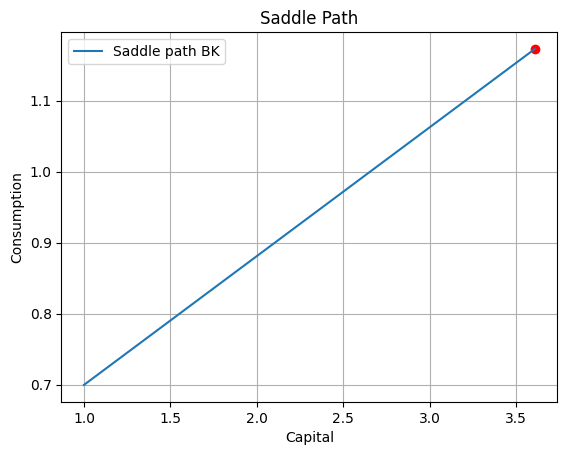

In [6]:
plt.plot(k_SS, c_SS, marker = 'o', color='red')
plt.plot(k_bk_real, c_bk_real, label='Saddle path BK')
plt.title('Saddle Path')
plt.xlabel('Capital')
plt.ylabel('Consumption')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Backward Euler method with Blanchrd-Kahn start

In [7]:
# Расчёт значений
epsilon = 0.000001

k_bk_bw = np.zeros(N)                          # В относительных величинах (отклонение от SS)
c_bk_bw = np.zeros(N)                          # В относительных величинах (отклонение от SS)
k_bk_bw_real = np.zeros(N)                     # В абсолютных величинах
c_bk_bw_real = np.zeros(N)                     # В абсолютных величинах

# Пусть  начальное K = 1.0 . Это то же самое, что отклонение от k_ss на ((1.0 - k_SS) / k_SS) в %
k_bk_bw_real[0] =  k_SS - epsilon                         # В абсолютных величинах
k_bk_bw[0]      = (k_bk_bw_real[0] - k_SS )/k_SS          # В относительных величинах (отклонение от SS)
c_bk_bw[0]      = -Q[num, 0] / Q[num, 1] * k_bk_bw[0]     # В относительных величинах (отклонение от SS)
c_bk_bw_real[0] = c_bk_bw[0] * c_SS + c_SS                # В абсолютных величинах

print(c_bk_bw[0])

for t in range(1, N):

    c_bk_bw_real[t] = c_bk_bw_real[t-1] * ( beta*( 1-delta+alpha*A*(k_bk_bw_real[t-1]**(alpha-1)) ) )**(-1.0)  # N => 0, N-1 = 1
    bkw_func = lambda x: x**alpha + (1 - delta) * x - c_bk_bw_real[t] - k_bk_bw_real[t - 1]
    k_bk_bw_real[t] = fsolve(bkw_func, k_bk_bw_real[t - 1]+epsilon )[0]
    
    #print(k_bk_bw_real[t-1])
    #print(c_bk_bw_real[t-1])
#k_bk_bw_real

-1.5464931463473698e-07


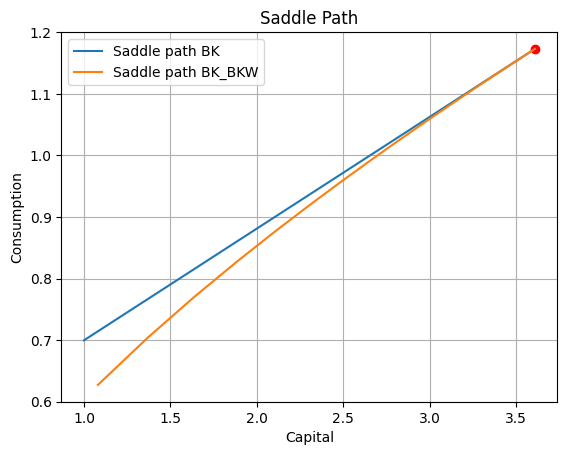

In [8]:
plt.plot(k_SS, c_SS, marker = 'o', color='red')
plt.plot(k_bk_real, c_bk_real, label='Saddle path BK')
plt.plot(k_bk_bw_real, c_bk_bw_real, label='Saddle path BK_BKW')
plt.title('Saddle Path')
plt.xlabel('Capital')
plt.ylabel('Consumption')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Shooting Method

In [9]:
c_min = 0;
c_max = c_SS;

L = 1000; #number of periods of simulation
k = np.zeros((L,))
c = np.zeros((L,))

k[0] = 1.0;
c[0] = 0.5;
t=1
tmax = 1
tot_check = 1
k_check = k[0]

while (t < L) and (tot_check > 0):

    if (abs(c_SS-c[t-1])>0.0001) or (abs(k_SS-k[t-1])>0.0001):
        ck_check = 0
        k[t] = A*k[t-1]**alpha + (1-delta)*k[t-1]-c[t-1];
        c[t] = beta*(1-delta+alpha*A*k[t]**(alpha-1))*c[t-1]; 
        
        if k[t]-k[t-1]<0:
            c_max = c[0];
            c[0]=(c[0]+c_min)/2;
            t=1; ck_check = 1
            #print('t = ',t,'; new c[1]', c[1])

        if c[t]-c[t-1]<0:
            c_min = c[0];
            c[0]=(c[0]+c_max)/2;
            t=1; ck_check = 1
            #print('t = ',t,'; new c[1]', c[1])
        
        if ck_check == 0:
            t=t+1
            if t>tmax: 
                tmax = t
                #print(tmax)
    else:
        tot_check = 0
    

print(tmax, k[0], c[0], k[tmax-1], c[tmax-1])
k_sh = k[0:(tmax-1)]
c_sh = c[0:(tmax-1)]

64 1.0 0.6044576981143498 3.6088133207568083 1.1729963263199656


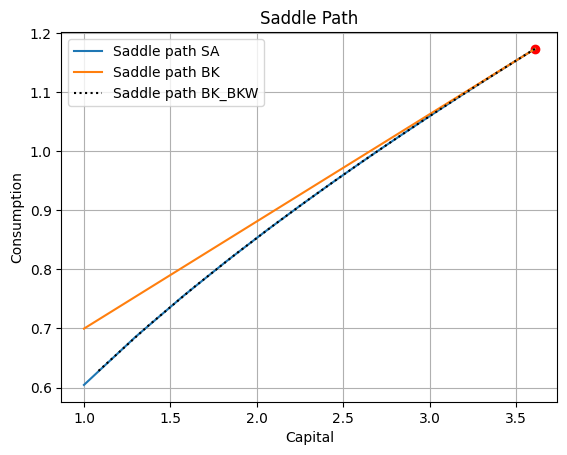

In [10]:
plt.plot(k_SS, c_SS, marker = 'o', color='red')
plt.plot(k_sh, c_sh, label='Saddle path SA')
plt.plot(k_bk_real, c_bk_real, label='Saddle path BK')
plt.plot(k_bk_bw_real, c_bk_bw_real, linestyle = ':', color='black', label='Saddle path BK_BKW')
plt.title('Saddle Path')
plt.xlabel('Capital')
plt.ylabel('Consumption')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Value Function Iteration

In [11]:
# Сетка капитала
k_min = 1
k_max = 1.5*k_SS
n = 2000  # число узлов сетки

g   = np.linspace(0, 1, n).reshape(n, 1)   # g:   [n x 1]
k_g = k_min + (k_max - k_min) * g          # k_g: [n x 1]
k_g

k_g_row = np.tile(k_g, (1, n))             # [n x n], текущий капитал
k_g_col = k_g_row.T                        # [n x n], будущий капитал

In [12]:
# Подготовка и начальное приближение

c_g = A * k_g_row**alpha + (1 - delta) * k_g_row - k_g_col
c_g = np.maximum(c_g, 1e-8)  # Неотрицательное потребление
U   = np.log(c_g)

# Инициализация функции ценности 
V = np.zeros((n, 2))   # Функция ценности для текщего (0) и будущего (1) периода
#V[:, 0] = np.full(n, np.log(k_SS) / (1 - beta))  # начальная V-функция (начальное приближение приближение)
I = np.zeros((n, 2), dtype=int)

# Первая итерация
V[:, 1] = np.max(U + beta * V[:, 0].reshape(1, -1), axis=1)
I[:, 1] = np.argmax(U + beta * V[:, 0].reshape(1, -1), axis=1)

In [13]:
t = 2
while True:
    V_new = np.max(   U + beta * V[:, 1].reshape(1, -1), axis=1)
    I_new = np.argmax(U + beta * V[:, 1].reshape(1, -1), axis=1)

    if np.max(np.abs(V_new - V[:, 1])) < 1e-6:
        break
    
    V = np.column_stack((V[:, 1], V_new))
    I = np.column_stack((I[:, 1], I_new))
    t += 1

print(t)

278


In [14]:
opt_k = k_g[I_new]  # оптимальный капитал в следующем периоде
opt_V = V_new       # итоговая функция ценности
opt_c = A * k_g.flatten()**alpha + (1 - delta) * k_g.flatten() - opt_k.flatten() # оптимальное потребление для каждого узла сетки

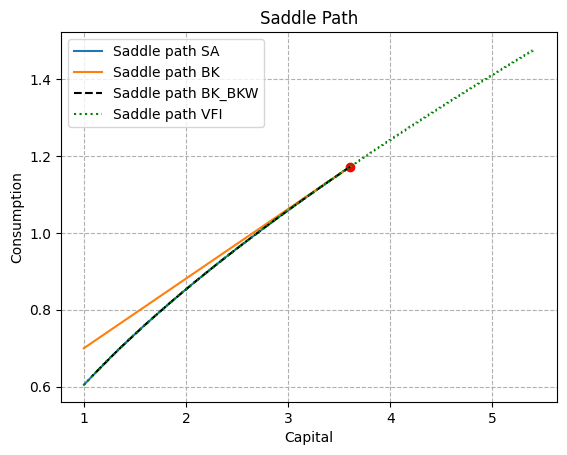

In [15]:
plt.plot(k_SS, c_SS, marker = 'o', color='red')
plt.plot(k_sh, c_sh, label='Saddle path SA')
plt.plot(k_bk_real, c_bk_real, label='Saddle path BK')
plt.plot(k_bk_bw_real, c_bk_bw_real, linestyle = '--', color='black', label='Saddle path BK_BKW')
plt.plot(k_g.flatten(), opt_c, linestyle = ':', color='green', label='Saddle path VFI')

plt.title('Saddle Path')
plt.xlabel('Capital')
plt.ylabel('Consumption')
plt.legend(loc='best')
plt.grid(True, linestyle = '--')
plt.show()